In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [105]:
df = pd.read_csv('01-ecommerce-orders.csv')

In [137]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# 2. BASIC DATA INFORMATION
# ============================================================

print("\n--- Dataset Information ---")
print(df.info())

print("\n--- Statistical Summary ---")
print(df.describe(include="all"))

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows ---")
print(df.duplicated().sum())


# ============================================================
# 3. STANDARDIZE COLUMN NAMES
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 4. CLEAN TEXT COLUMNS
# ============================================================

text_columns = df.select_dtypes(include="object").columns

for col in text_columns:
    df[col] = df[col].str.strip()


# ============================================================
# 5. CLEAN ORDER DATE
# ============================================================

df["order_date"] = pd.to_datetime(
    df["order_date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

print("\nDate Data Type:")
print(df["order_date"].dtype)

print("\nInvalid Dates:")
print(df["order_date"].isna().sum())


# ============================================================
# 6. CLEAN NUMERIC COLUMNS
# ============================================================

numeric_columns = [
    "quantity",
    "unit_price",
    "order_total",
    "weight"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# 7. CHECK DUPLICATES
# ============================================================

print("\nDuplicate Rows:", df.duplicated().sum())

print("Duplicate Order IDs:", df["order_id"].duplicated().sum())

# Remove exact duplicate rows
df = df.drop_duplicates()


# ============================================================
# 8. CHECK INVALID QUANTITY
# ============================================================

print("\nInvalid Quantity:")
print(df[df["quantity"] <= 0])

# Create flag instead of immediately deleting
df["invalid_quantity"] = df["quantity"] <= 0


# ============================================================
# 9. CHECK INVALID PRICE
# ============================================================

print("\nInvalid Unit Price:")
cprint(df[df["unit_price"] <= 0])

df["invalid_price"] = df["unit_price"] <= 0


# ============================================================
# 10. CALCULATE REVENUE
# ============================================================

df["calculated_revenue"] = (
    df["quantity"] * df["unit_price"]
)

print("\nRevenue Preview:")
print(
    df[
        [
            "order_id",
            "quantity",
            "unit_price",
            "calculated_revenue"
        ]
    ].head()
)


# ============================================================
# 11. VALIDATE ORDER TOTAL
# ============================================================

df["total_difference"] = (
    df["order_total"] -
    df["calculated_revenue"]
).abs()

df["total_check"] = (
    df["total_difference"] <=
    (df["calculated_revenue"].abs() * 0.01 + 0.01)
)

print("\nOrder Total Mismatches:")
print((~df["total_check"]).sum())


# ============================================================
# 12. CREATE DATE ANALYSIS COLUMNS
# ============================================================

df["year"] = df["order_date"].dt.year

df["month"] = df["order_date"].dt.month

df["month_name"] = df["order_date"].dt.month_name()

df["year_month"] = (
    df["order_date"]
    .dt.to_period("M")
    .astype(str)
)

df["day_name"] = (
    df["order_date"]
    .dt.day_name()
)


# ============================================================
# 13. CHECK UNIQUE VALUES
# ============================================================

print("\n--- Unique Values ---")

for col in df.columns:
    print(
        f"{col}: {df[col].nunique()}"
    )


# ============================================================
# 14. FINAL DATA QUALITY REPORT
# ============================================================

quality_report = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing %": (
        df.isnull().mean() * 100
    ).round(2),
    "Unique Values": df.nunique()
})

print("\n--- FINAL DATA QUALITY REPORT ---")
print(quality_report)




Dataset Shape: (3000, 23)

First 5 Rows:
     order_id order_date            customer_email  country  channel  \
0  ORD-101805 2026-03-19  customer0457@example.com   France   direct   
1  ORD-102690 2026-05-19  customer0814@example.com   France   social   
2  ORD-101454 2026-06-14  customer0858@example.com       UK    email   
3  ORD-100450 2026-01-08  customer0116@example.com       UK  organic   
4  ORD-101501 2026-05-20  customer1397@example.com  Ireland    email   

  product_sku       product_name  quantity  unit_price  order_total  ...  \
0     FR-9902     Trekking Poles         1        45.0         36.0  ...   
1     FR-2210    Trail Softshell         1        71.1         71.1  ...   
2     FR-1120    Fell Runner Cap         1        45.0         45.0  ...   
3     FR-5567  Merino Base Layer         1        71.1         71.1  ...   
4     FR-8890  Summit Down Gilet         1        21.6         21.6  ...   

   invalid_quantity invalid_price calculated_revenue  total_differenc

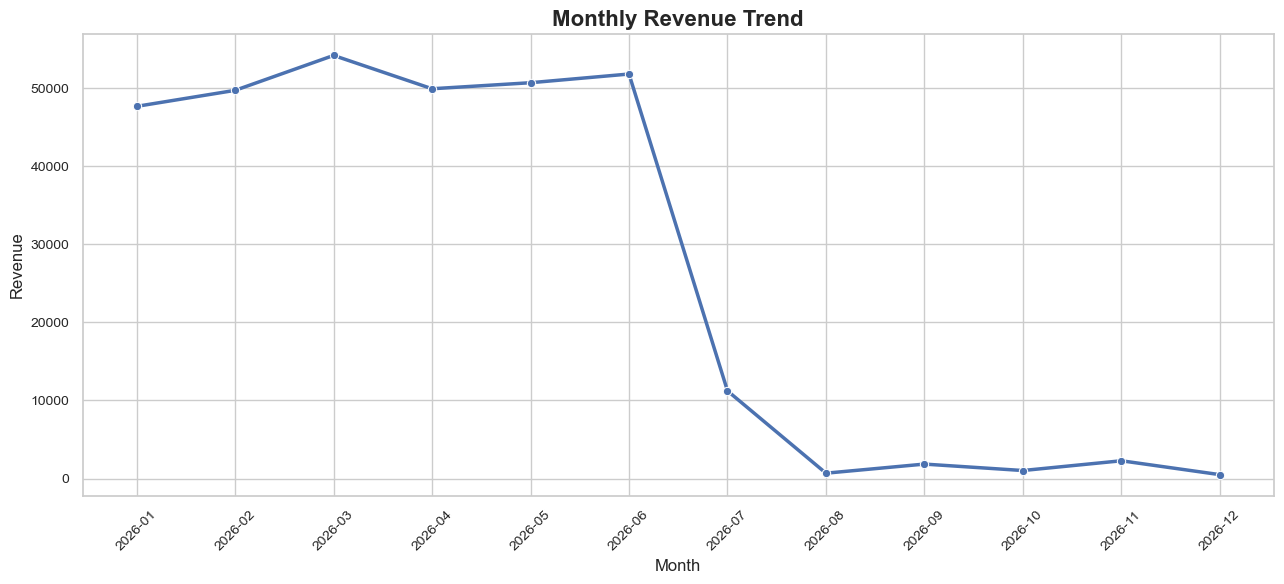

In [115]:
monthly_revenue = (
    df.groupby("year_month", as_index=False)
      .agg(
          revenue=("calculated_revenue", "sum")
      )
)

plt.figure(figsize=(13, 6))

sns.lineplot(
    data=monthly_revenue,
    x="year_month",
    y="revenue",
    marker="o",
    linewidth=2.5
)

plt.title("Monthly Revenue Trend", fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

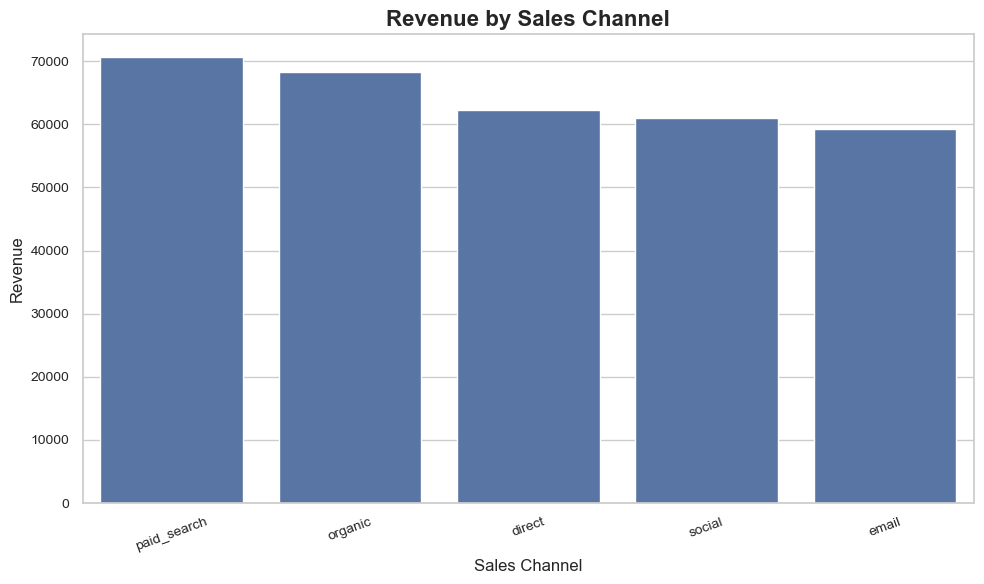

In [119]:
channel_revenue = (
    df.groupby("channel", as_index=False)
      .agg(
          revenue=("calculated_revenue", "sum")
      )
      .sort_values("revenue", ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=channel_revenue,
    x="channel",
    y="revenue"
)

plt.title(
    "Revenue by Sales Channel",
    fontweight="bold"
)

plt.xlabel("Sales Channel")
plt.ylabel("Revenue")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

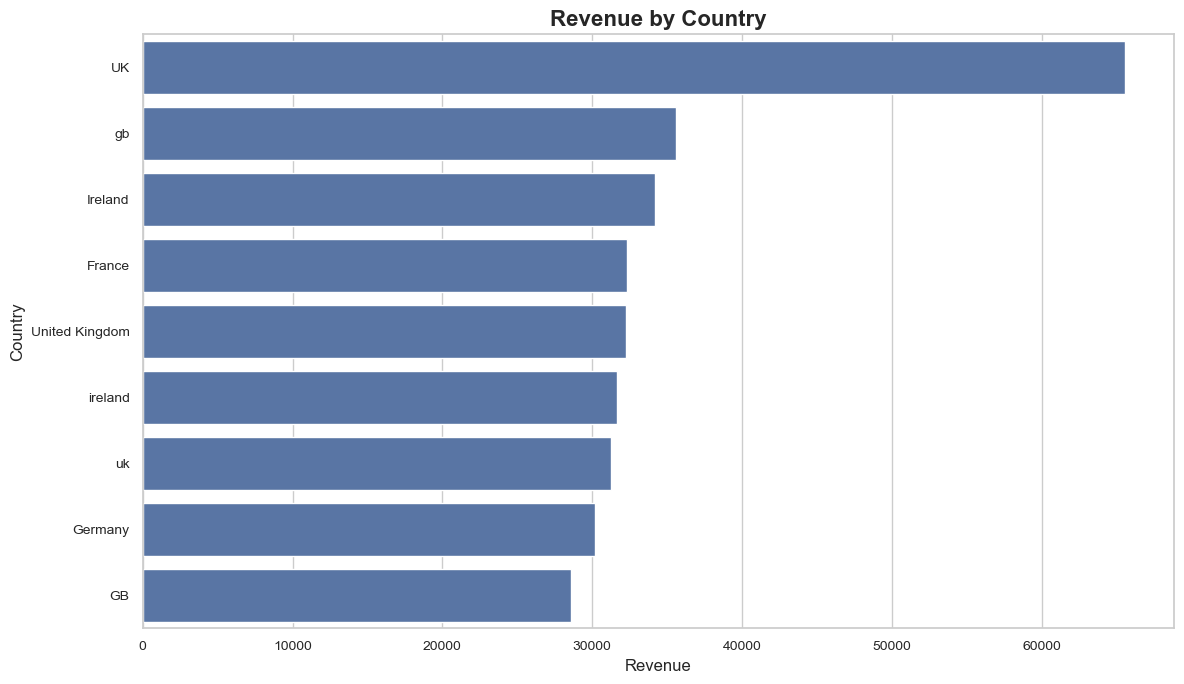

In [121]:
country_revenue = (
    df.groupby("country", as_index=False)
      .agg(
          revenue=("calculated_revenue", "sum")
      )
      .sort_values("revenue", ascending=False)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=country_revenue,
    x="revenue",
    y="country"
)

plt.title(
    "Revenue by Country",
    fontweight="bold"
)

plt.xlabel("Revenue")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

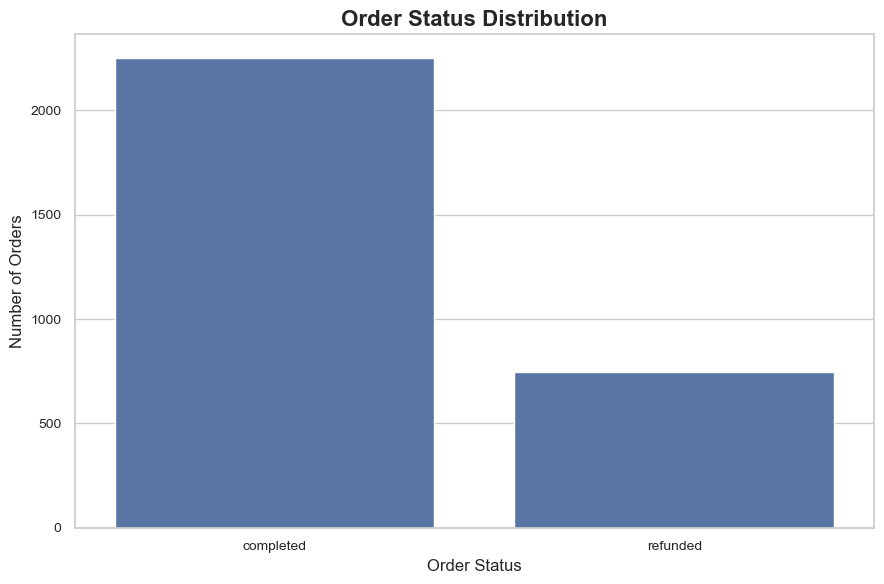

In [123]:
status_count = (
    df["status"]
    .value_counts()
    .reset_index()
)

status_count.columns = [
    "status",
    "orders"
]

plt.figure(figsize=(9, 6))

sns.barplot(
    data=status_count,
    x="status",
    y="orders"
)

plt.title(
    "Order Status Distribution",
    fontweight="bold"
)

plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

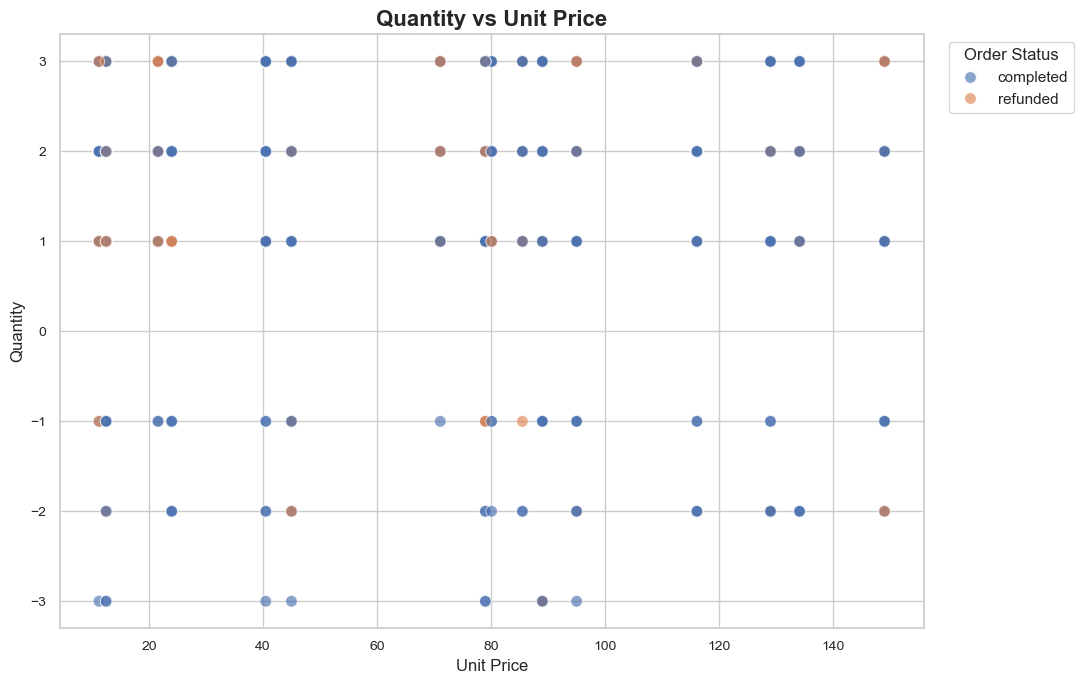

In [125]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df,
    x="unit_price",
    y="quantity",
    hue="status",
    alpha=0.65,
    s=70
)

plt.title(
    "Quantity vs Unit Price",
    fontweight="bold"
)

plt.xlabel("Unit Price")
plt.ylabel("Quantity")

plt.legend(
    title="Order Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

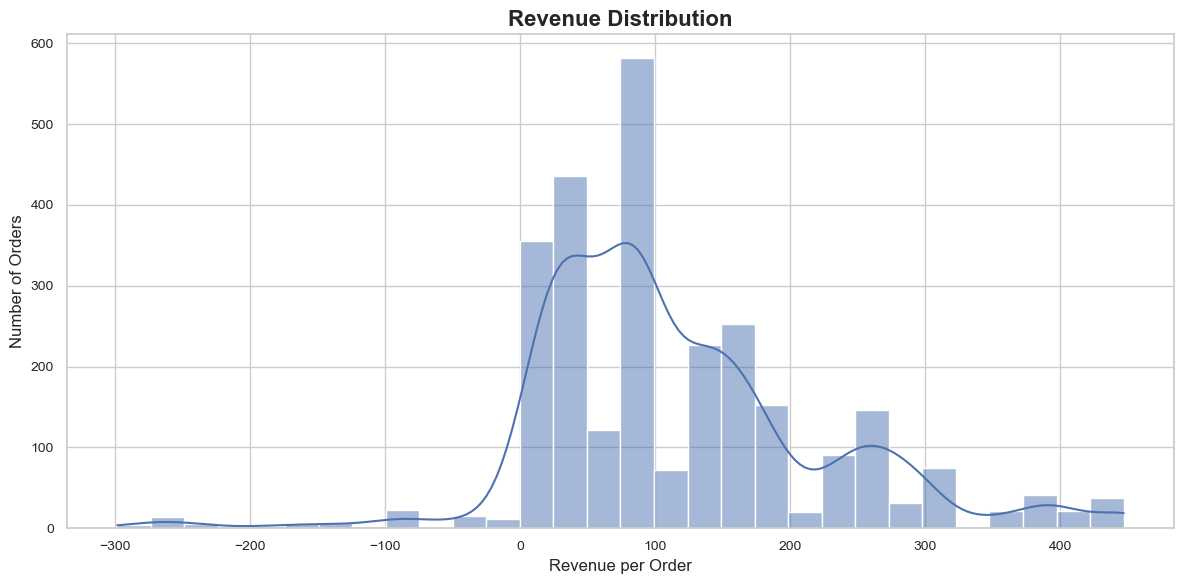

In [127]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="calculated_revenue",
    bins=30,
    kde=True
)

plt.title(
    "Revenue Distribution",
    fontweight="bold"
)

plt.xlabel("Revenue per Order")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

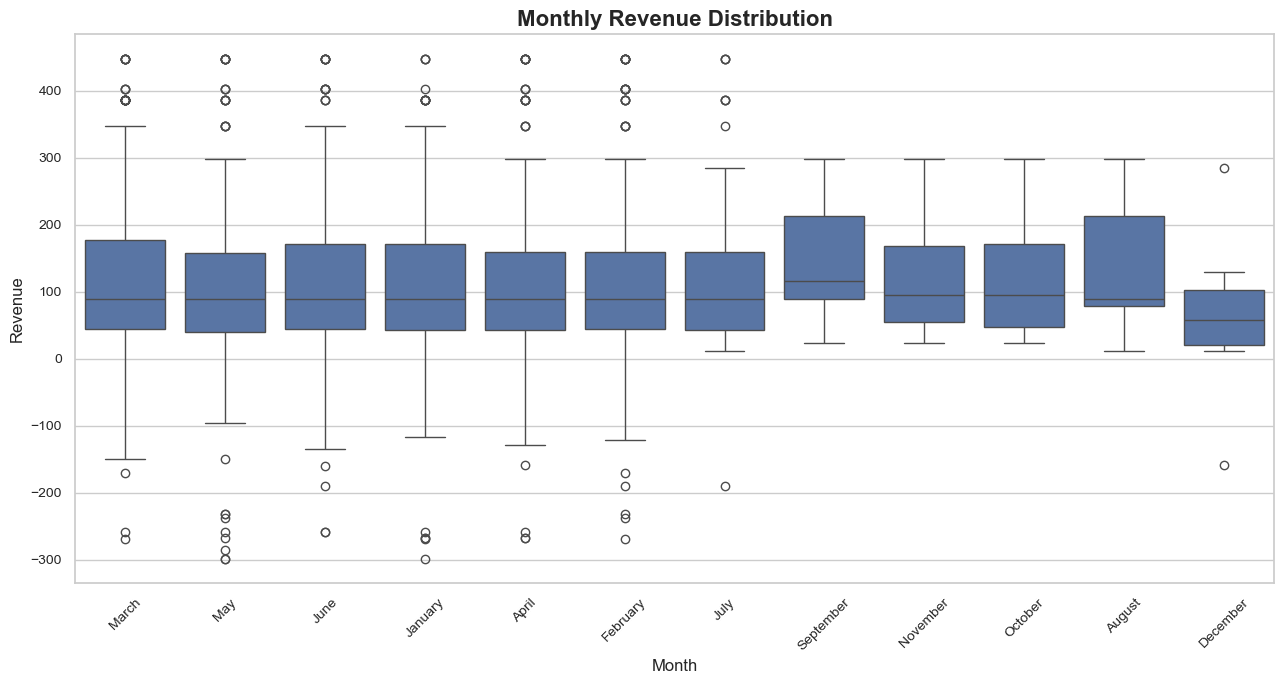

In [129]:
plt.figure(figsize=(13, 7))

sns.boxplot(
    data=df,
    x="month_name",
    y="calculated_revenue"
)

plt.title(
    "Monthly Revenue Distribution",
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

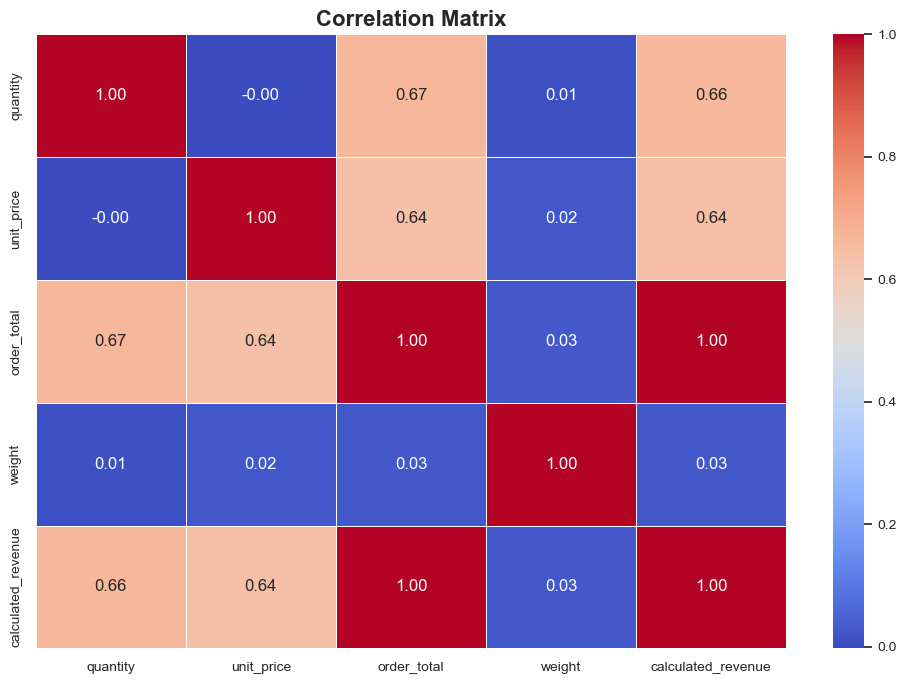

In [131]:
numeric_df = df[
    [
        "quantity",
        "unit_price",
        "order_total",
        "weight",
        "calculated_revenue"
    ]
].copy()

correlation = numeric_df.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

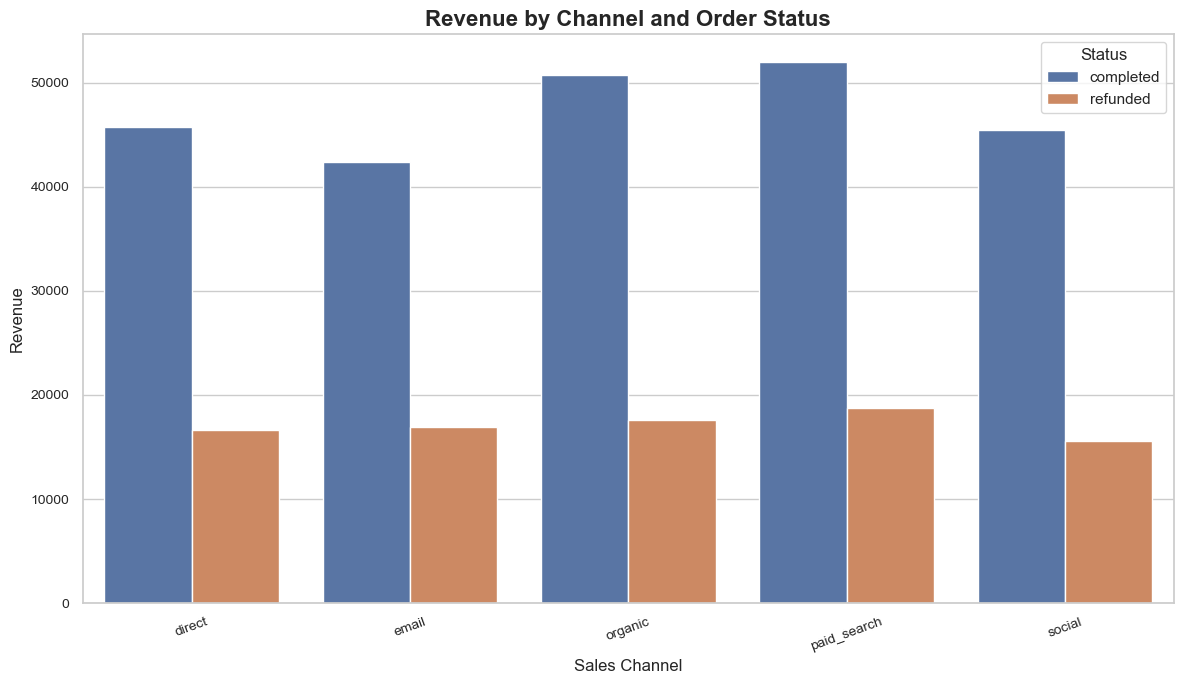

In [133]:
channel_status = (
    df.groupby(
        ["channel", "status"],
        as_index=False
    )
    .agg(
        revenue=("calculated_revenue", "sum")
    )
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=channel_status,
    x="channel",
    y="revenue",
    hue="status"
)

plt.title(
    "Revenue by Channel and Order Status",
    fontweight="bold"
)

plt.xlabel("Sales Channel")
plt.ylabel("Revenue")

plt.xticks(rotation=20)

plt.legend(
    title="Status"
)

plt.tight_layout()
plt.show()

In [141]:
df.isnull().sum()

order_id                0
order_date              0
customer_email          0
country                 0
channel                 0
product_sku             0
product_name            0
quantity                0
unit_price            228
order_total             0
weight                  0
currency                0
status                  0
invalid_quantity        0
invalid_price           0
calculated_revenue    228
total_difference      228
total_check             0
year                    0
month                   0
month_name              0
year_month              0
day_name                0
dtype: int64

In [143]:
df[df["unit_price"].isna()][
    [
        "order_id",
        "product_name",
        "product_sku",
        "quantity",
        "unit_price",
        "order_total",
        "currency"
    ]
].head(20)

,order_id,product_name,product_sku,quantity,unit_price,order_total,currency
29,ORD-100053,Trail Softshell,FR-2210,1,NaN,36.00,GBP
33,ORD-101025,Alpine Jacket,FR-4471,2,NaN,160.20,EUR
34,ORD-101946,Alpine Jacket,FR-4471,2,NaN,25.00,GBP
43,ORD-102266,CafÃ© Latte Mug,FR-3345,1,NaN,80.10,GBP
46,ORD-102860,Alpine Jacket,FR-4471,2,NaN,171.00,GBP
57,ORD-102733,Trail Softshell,FR-2210,1,NaN,116.10,EUR
76,ORD-102005,Trekking Poles,FR-9902,2,NaN,232.20,GBP
109,ORD-102552,Alpine Jacket,FR-4471,2,NaN,160.20,GBP
118,ORD-101311,Storm Overtrousers,FR-7781,1,NaN,24.00,GBP
150,ORD-101114,Alpine Jacket,FR-4471,2,NaN,142.20,GBP


In [145]:
df["recovered_unit_price"] = (
    df["order_total"] / df["quantity"]
)

df.loc[
    df["unit_price"].isna(),
    "unit_price"
] = df.loc[
    df["unit_price"].isna(),
    "recovered_unit_price"
]

In [147]:
print("Missing unit_price:",
      df["unit_price"].isna().sum())

Missing unit_price: 0


In [149]:
df["calculated_revenue"] = (
    df["quantity"] * df["unit_price"]
)


In [151]:
print(df[
    [
        "order_id",
        "quantity",
        "unit_price",
        "order_total",
        "calculated_revenue"
    ]
].head(10))

     order_id  quantity  unit_price  order_total  calculated_revenue
0  ORD-101805         1        45.0         36.0                45.0
1  ORD-102690         1        71.1         71.1                71.1
2  ORD-101454         1        45.0         45.0                45.0
3  ORD-100450         1        71.1         71.1                71.1
4  ORD-101501         1        21.6         21.6                21.6
5  ORD-101788         1        45.0         45.0                45.0
6  ORD-102657         3        85.5        256.5               256.5
7  ORD-102047         2       134.1        268.2               268.2
8  ORD-102650         1        24.0         24.0                24.0
9  ORD-102734         1        95.0         95.0                95.0


In [153]:
df.isnull().sum()

order_id                  0
order_date                0
customer_email            0
country                   0
channel                   0
product_sku               0
product_name              0
quantity                  0
unit_price                0
order_total               0
weight                    0
currency                  0
status                    0
invalid_quantity          0
invalid_price             0
calculated_revenue        0
total_difference        228
total_check               0
year                      0
month                     0
month_name                0
year_month                0
day_name                  0
recovered_unit_price      0
dtype: int64

In [155]:
# Recalculate revenue after recovering unit_price
df["calculated_revenue"] = (
    df["quantity"] * df["unit_price"]
)

# Recalculate difference
df["total_difference"] = (
    df["order_total"] - df["calculated_revenue"]
).abs()

# Recalculate validation
df["total_check"] = (
    df["total_difference"]
    <= (df["calculated_revenue"].abs() * 0.01 + 0.01)
)

# Check missing values
print(df.isnull().sum())

order_id                0
order_date              0
customer_email          0
country                 0
channel                 0
product_sku             0
product_name            0
quantity                0
unit_price              0
order_total             0
weight                  0
currency                0
status                  0
invalid_quantity        0
invalid_price           0
calculated_revenue      0
total_difference        0
total_check             0
year                    0
month                   0
month_name              0
year_month              0
day_name                0
recovered_unit_price    0
dtype: int64


In [157]:
mismatches = df[df["total_check"] == False]

print("Total mismatched orders:", len(mismatches))

mismatches[
    [
        "order_id",
        "quantity",
        "unit_price",
        "order_total",
        "calculated_revenue",
        "total_difference"
    ]
].head(20)

Total mismatched orders: 192


,order_id,quantity,unit_price,order_total,calculated_revenue,total_difference
0,ORD-101805,1,45.00,36.00,45.0,9.00
56,ORD-101237,2,95.00,171.00,190.0,19.00
70,ORD-102523,1,129.00,103.20,129.0,25.80
117,ORD-100431,1,24.00,20.40,24.0,3.60
124,ORD-102810,3,129.00,348.30,387.0,38.70
160,ORD-102787,2,11.25,20.25,22.5,2.25
161,ORD-101204,1,45.00,40.50,45.0,4.50
166,ORD-101010,1,95.00,76.00,95.0,19.00
210,ORD-102628,1,116.10,98.68,116.1,17.42
241,ORD-101129,2,12.50,21.25,25.0,3.75


In [159]:
print("========== FINAL DATA QUALITY ==========")

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nInvalid Quantity:")
print((df["quantity"] <= 0).sum())

print("\nInvalid Price:")
print((df["unit_price"] <= 0).sum())

print("\nOrder Total Mismatches:")
print((df["total_check"] == False).sum())

========== FINAL DATA QUALITY ==========
Rows: 3000
Columns: 24

Missing Values:
order_id                0
order_date              0
customer_email          0
country                 0
channel                 0
product_sku             0
product_name            0
quantity                0
unit_price              0
order_total             0
weight                  0
currency                0
status                  0
invalid_quantity        0
invalid_price           0
calculated_revenue      0
total_difference        0
total_check             0
year                    0
month                   0
month_name              0
year_month              0
day_name                0
recovered_unit_price    0
dtype: int64

Duplicate Rows:
0

Invalid Quantity:
102

Invalid Price:
0

Order Total Mismatches:
192


In [161]:

df.to_csv(
    "ecommerce_cleaned.csv",
    index=False
)

print("CSV file created successfully!")

CSV file created successfully!
